# Centroids

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [1]:
# Northeastern USA Town data (useful for your final project!)
# https://drive.google.com/file/d/1cEZBYENFaJ59R1nm0M0E9Q2rqZI6_Yc2/view?usp=sharing
!gdown 1cEZBYENFaJ59R1nm0M0E9Q2rqZI6_Yc2

Downloading...
From: https://drive.google.com/uc?id=1cEZBYENFaJ59R1nm0M0E9Q2rqZI6_Yc2
To: /content/Connecticut_and_Vicinity_Town_Boundary_Set_2617795301392764759.zip
100% 3.30M/3.30M [00:00<00:00, 33.8MB/s]


In [2]:
!unzip Connecticut_and_Vicinity_Town_Boundary_Set_2617795301392764759.zip

Archive:  Connecticut_and_Vicinity_Town_Boundary_Set_2617795301392764759.zip
  inflating: CT_Vicinity_Town_Polygon.cpg  
  inflating: CT_Vicinity_Town_Polygon.dbf  
  inflating: CT_Vicinity_Town_Polygon.prj  
  inflating: CT_Vicinity_Town_Polygon.shp  
  inflating: CT_Vicinity_Town_Polygon.shx  


Index(['LAND_CLASS', 'CT_LEGEND', 'STATE_COD', 'STATE_NAME', 'CNTY_FIELD',
       'CNTY_COD', 'CNTY_NAME', 'TOWN_FIELD', 'TOWN_NAME', 'LABEL_FLAG',
       'MAP_LABEL', 'CT_LABEL_Y', 'CT_LABEL_N', 'geometry'],
      dtype='object')


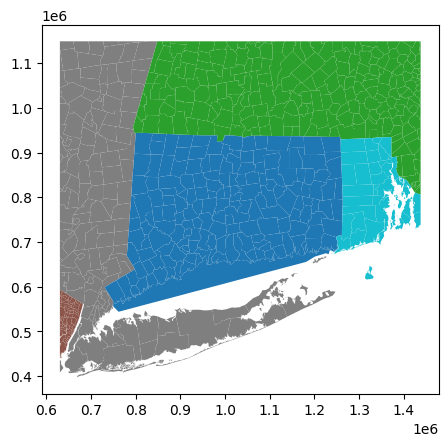

In [7]:
towns = gpd.read_file('CT_Vicinity_Town_Polygon.shp')
print(towns.columns)
towns.plot(column='STATE_COD')
plt.show()

In [10]:
# prompt: convert the crs to wgs84

towns = towns.to_crs('EPSG:4326')


In [11]:
# prompt: make a new field for the lat lon centroid of each polygon

towns['centroid'] = towns.centroid
towns.head()

<ipython-input-11-ac40c83e4cdf>:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  towns['centroid'] = towns.centroid


,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,MAP_LABEL,CT_LABEL_Y,CT_LABEL_N,geometry,centroid
0,Land,Other States,MA,Massachusetts,FIPS-COUNTY,27.0,Worcester,TOWN-ID,Uxbridge,True,Uxbridge,None,Uxbridge,"POLYGON ((-71.59192 42.06371, -71.59273 42.114...",POINT (-71.63758 42.05937)
1,Land,Other States,MA,Massachusetts,FIPS-COUNTY,21.0,Norfolk,TOWN-ID,Foxborough,True,Foxborough,None,Foxborough,"POLYGON ((-71.17836 42.05746, -71.19620 42.082...",POINT (-71.24609 42.06271)
2,Land,Other States,MA,Massachusetts,FIPS-COUNTY,27.0,Worcester,TOWN-ID,Southbridge,True,Southbridge,None,Southbridge,"POLYGON ((-71.99294 42.07255, -71.99257 42.078...",POINT (-72.03386 42.05992)
3,Land,Other States,MA,Massachusetts,FIPS-COUNTY,5.0,Bristol,TOWN-ID,Easton,True,Easton,None,Easton,"POLYGON ((-71.14082 41.99879, -71.13898 42.072...",POINT (-71.15118 42.03717)
4,Land,Other States,MA,Massachusetts,FIPS-COUNTY,13.0,Hamden,TOWN-ID,Agawam,True,Agawam,None,Agawam,"POLYGON ((-72.58852 42.09324, -72.58877 42.093...",POINT (-72.65257 42.06577)


In [13]:
# prompt: make a new field for lat and lon from centroid

towns['latitude'] = towns['centroid'].y
towns['longitude'] = towns['centroid'].x
towns.head()

,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,MAP_LABEL,CT_LABEL_Y,CT_LABEL_N,geometry,centroid,latitude,longitude
0,Land,Other States,MA,Massachusetts,FIPS-COUNTY,27.0,Worcester,TOWN-ID,Uxbridge,True,Uxbridge,None,Uxbridge,"POLYGON ((-71.59192 42.06371, -71.59273 42.114...",POINT (-71.63758 42.05937),42.059366,-71.637578
1,Land,Other States,MA,Massachusetts,FIPS-COUNTY,21.0,Norfolk,TOWN-ID,Foxborough,True,Foxborough,None,Foxborough,"POLYGON ((-71.17836 42.05746, -71.19620 42.082...",POINT (-71.24609 42.06271),42.062710,-71.246088
2,Land,Other States,MA,Massachusetts,FIPS-COUNTY,27.0,Worcester,TOWN-ID,Southbridge,True,Southbridge,None,Southbridge,"POLYGON ((-71.99294 42.07255, -71.99257 42.078...",POINT (-72.03386 42.05992),42.059920,-72.033864
3,Land,Other States,MA,Massachusetts,FIPS-COUNTY,5.0,Bristol,TOWN-ID,Easton,True,Easton,None,Easton,"POLYGON ((-71.14082 41.99879, -71.13898 42.072...",POINT (-71.15118 42.03717),42.037169,-71.151181
4,Land,Other States,MA,Massachusetts,FIPS-COUNTY,13.0,Hamden,TOWN-ID,Agawam,True,Agawam,None,Agawam,"POLYGON ((-72.58852 42.09324, -72.58877 42.093...",POINT (-72.65257 42.06577),42.065770,-72.652571


In [14]:
# prompt: select only connecticut

towns_ct = towns[towns['STATE_COD'] == 'CT']
towns_ct.shape

(784, 17)

<Axes: >

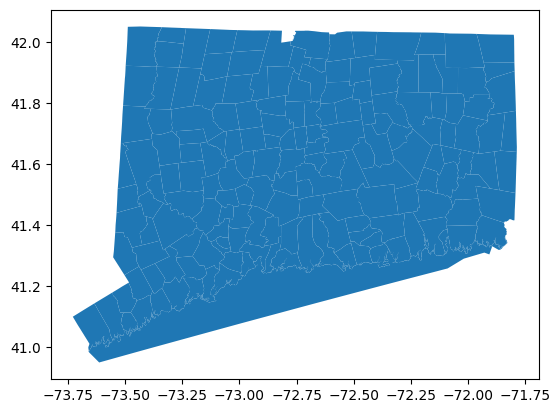

In [15]:
towns_ct.plot()

In [17]:
towns_ct.head()

,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,MAP_LABEL,CT_LABEL_Y,CT_LABEL_N,geometry,centroid,latitude,longitude
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,Salisbury,Salisbury,None,"POLYGON ((-73.34064 42.04836, -73.34434 42.048...",POINT (-73.42566 41.98602),41.986020,-73.425663
25,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,North Canaan,True,North Canaan,North Canaan,None,"POLYGON ((-73.29629 42.04699, -73.30315 42.047...",POINT (-73.29356 42.02226),42.022262,-73.293565
26,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Norfolk,True,Norfolk,Norfolk,None,"POLYGON ((-73.17214 42.04339, -73.18613 42.043...",POINT (-73.19622 41.98015),41.980147,-73.196216
27,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Colebrook,True,Colebrook,Colebrook,None,"POLYGON ((-73.05308 42.03978, -73.05856 42.039...",POINT (-73.08080 42.00155),42.001548,-73.080800
28,Land,Connecticut,CT,Connecticut,CNTY_COD,2.0,Hartford,TOWN_NO,Hartland,True,Hartland,Hartland,None,"POLYGON ((-72.97902 42.03825, -72.97983 42.038...",POINT (-72.94890 42.00429),42.004291,-72.948900


<Axes: >

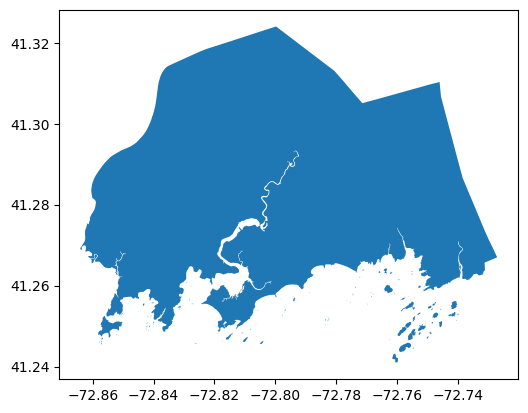

In [18]:
# prompt: make a plot of branford ct

branford = towns_ct[towns_ct['TOWN_NAME'] == 'Branford']
branford.plot()


In [21]:
# prompt: take average lat lon per TOWN_NAME in towns_ct

towns_ct_avg = towns_ct.groupby('TOWN_NAME').mean()[['latitude', 'longitude']]
towns_ct_avg

<ipython-input-21-11d8754326f3>:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  towns_ct_avg = towns_ct.groupby('TOWN_NAME').mean()[['latitude', 'longitude']]


,latitude,longitude
TOWN_NAME,,
Andover,41.733135,-72.376108
Ansonia,41.344272,-73.068894
Ashford,41.891115,-72.170985
Avon,41.790701,-72.854024
Barkhamsted,41.931582,-72.972948
...,...,...
Windsor Locks,41.926789,-72.654842
Wolcott,41.600673,-72.973181
Woodbridge,41.356610,-73.010033


In [22]:
towns_ct_avg.to_csv('CT_centroids.csv')